<a href="https://colab.research.google.com/github/fourmodern/cellvit-tutorial/blob/main/03_HNE2Cell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HNE2Cell 튜토리얼: H&E에서 15종 세포를 전사체 수준으로 분류하기

**HNE2Cell**은 H&E 전체 슬라이드 이미지(WSI)에서 세포핵을 검출·분할하고 **15종 세포 타입**으로 분류하는 모델입니다. 모델, 추론 코드, 예제 슬라이드가 HuggingFace([`roobee79/HNE2Cell`](https://huggingface.co/roobee79/HNE2Cell))에 공개되어 있습니다. 공개 README의 인용 제목(*Spatial transcriptomics–supervised deep learning enables single-cell mapping of tumor immune architecture from routine histology*)대로, **공간전사체에서 정한 세포 타입을 정답으로 학습**한 것이 특징입니다.

```
  공간전사체: 유전자 발현 → 세포 타입 라벨
     ▼ (같은 조직의 H&E에 정렬)
  H&E 256px 패치 → 224 축소 → 대형 ViT encoder (약 13억 파라미터) ─► CellViT식 디코더
                                                            ├─ 핵 분할 (핵 확률 + HV 맵)
                                                            └─ 픽셀별 세포 타입 (배경 + 15종)
```

| | CellViT | CellViT++ | **HNE2Cell** |
|---|---|---|---|
| 정답 라벨 출처 | 병리의 수작업(PanNuke) | 수작업 점 라벨 | **공간전사체** |
| Encoder | SAM-H / HIPT | SAM-H / HIPT (고정) | 대형 병리 ViT (약 1.3B 파라미터, 모델 전체 기준) |
| 세포 타입 | 5종 | 데이터셋별 2~7종 | **15종** (CD4/CD8 T, B, Plasma, Macrophage, DC, Fibroblast, Endothelial, Pericyte, ...) |
| 입력 | 1024px @ 40x | 1024px @ 40x | 256px @ 40x → 224로 축소 |

> 이 노트북은 HuggingFace에 공개된 모델·코드·README만 근거로 작성했습니다. 모델의 학습 데이터와 성능 평가는 공개 README의 인용 정보를 참고하세요.

### 이 노트북에서 하는 것

| § | 내용 |
|---|---|
| 1 | 모델·예제 슬라이드(TCGA 폐 편평세포암) 다운로드, 모델 출력 구조 확인 |
| 2 | Reinhard 색 정규화 (Colab 메모리에 맞춘 패치 단위 버전) |
| 3 | 패치 하나 추론: 원시 출력 → 세포 분할 → 15종 분류 → 5개 계통 그룹 |
| 4 | 슬라이드 영역(또는 전체) 추론 + 겹친 패치 중복 제거 |
| 5 | 세포 지도, 조성, 공간 분석 (면역세포 침윤, B/T 세포 군집 = TLS 후보) |
| 6 | CSV / QuPath GeoJSON 내보내기 |

**라이선스**: 코드 MIT, **모델 가중치 CC BY-NC 4.0 (비상업적 연구용)**. 모델·코드: https://huggingface.co/roobee79/HNE2Cell

## 0. 환경 설정

**Colab**: `런타임 → 런타임 유형 변경 → T4 GPU`. Colab 기본 패키지(torch, opencv, scikit-image, numba)를 그대로 쓰므로 **런타임 재시작이 필요 없습니다.**

필요 자원: GPU 메모리 약 6GB, 디스크 약 6GB (모델 5.1GB).

In [1]:
import sys, os, importlib.util
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if importlib.util.find_spec("openslide") is None:
    !pip -q install openslide-bin openslide-python

WORKDIR = Path("/content/hne2cell") if IN_COLAB else Path.cwd() / "hne2cell_work"
WORKDIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORKDIR)

# 모델(5.1GB)을 Google Drive에 캐시하면 다음 세션에서 재다운로드하지 않습니다.
USE_DRIVE_CACHE = False
if IN_COLAB and USE_DRIVE_CACHE:
    from google.colab import drive
    drive.mount("/content/drive")
    HF_CACHE = "/content/drive/MyDrive/hne2cell_cache"
else:
    HF_CACHE = str(WORKDIR.parent / "hne2cell_cache") if not IN_COLAB else str(WORKDIR / "hf_cache")
print("WORKDIR:", WORKDIR, "| HF cache:", HF_CACHE)

WORKDIR: /home/hjpark/dp/cellvit_tutorial/hne2cell_work | HF cache: /home/hjpark/dp/cellvit_tutorial/hne2cell_cache


## 1. 모델과 예제 데이터 받기 (HuggingFace `roobee79/HNE2Cell`)

| 파일 | 크기 | 용도 |
|---|---|---|
| `HNE2cell_pub_patch73_jit.pt` | 5.1 GB | TorchScript 모델 (ViT encoder + CellViT식 디코더) |
| `TCGA-56-8628-...svs` | 36 MB | 예제 WSI: TCGA 폐 편평세포암(LUSC), 40x |
| `standard-ilc.tif` | 355 MB | 색 정규화 기준 이미지 |
| `post_processing.py`, `tools.py` | - | 공식 후처리 (HoVer-Net/CellViT식 watershed) |

In [2]:
from huggingface_hub import hf_hub_download

REPO_ID = "roobee79/HNE2Cell"
SLIDE_NAME = "TCGA-56-8628-01Z-00-DX1.AAC57164-E0F9-4DF0-87EA-5C50FB201895.svs"
get = lambda f: hf_hub_download(REPO_ID, f, cache_dir=HF_CACHE)

for f in ["post_processing.py", "tools.py", "config.json"]:
    get(f)
CODE_DIR = Path(get("tools.py")).parent
sys.path.insert(0, str(CODE_DIR))  # 공식 post_processing 모듈 import용

SLIDE_PATH = get(SLIDE_NAME)
REF_PATH = get("standard-ilc.tif")
MODEL_PATH = get("HNE2cell_pub_patch73_jit.pt")  # 5.1GB, 수 분 소요
!ls -lhL {CODE_DIR}

합계 5.2G
-r--r--r-- 1 hjpark hjpark 4.8G 10월  5 16:10 HNE2cell_pub_patch73_jit.pt
-r--r--r-- 1 hjpark hjpark  35M 10월  5 16:09 TCGA-56-8628-01Z-00-DX1.AAC57164-E0F9-4DF0-87EA-5C50FB201895.svs
drwxrwxr-x 2 hjpark hjpark 4.0K 10월  5 16:17 __pycache__
-rw-rw-r-- 1 hjpark hjpark 1.3K 10월  5 16:17 config.json
-rw-rw-r-- 1 hjpark hjpark  14K 10월  5 16:16 post_processing.py
-r--r--r-- 1 hjpark hjpark 339M 10월  5 16:09 standard-ilc.tif
-rw-rw-r-- 1 hjpark hjpark  12K 10월  5 16:16 tools.py


In [3]:
import json, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt
import openslide, tifffile
from skimage import color
from post_processing import DetectionCellPostProcessor  # HuggingFace 공식 코드

warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 한글 폰트
import matplotlib.font_manager as fm, urllib.request
_font = WORKDIR / "NanumGothic-Regular.ttf"
if not _font.exists():
    urllib.request.urlretrieve("https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf", _font)
fm.fontManager.addfont(str(_font))
plt.rcParams["font.family"] = fm.FontProperties(fname=str(_font)).get_name()
plt.rcParams["axes.unicode_minus"] = False

# 공통 시각화 도구 viz.py: 저장소에 있으면 그대로, 없으면(Colab) GitHub에서 받기
for _d in [WORKDIR, WORKDIR.parent]:
    if (_d / "viz.py").exists():
        sys.path.insert(0, str(_d)); break
else:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/fourmodern/cellvit-tutorial/main/viz.py", WORKDIR / "viz.py")
    sys.path.insert(0, str(WORKDIR))
import viz

CONFIG = json.loads((CODE_DIR / "config.json").read_text())
CELL_TYPES = {int(k): v for k, v in CONFIG["id2label"].items()}  # 0=Background, 1~15
print("device:", DEVICE, "| torch", torch.__version__)
print(CELL_TYPES)

device: cuda | torch 2.2.2+cu121
{0: 'Background', 1: 'Malignant', 2: 'CD4 T', 3: 'CD8 T', 4: 'B', 5: 'Plasma', 6: 'Macrophage', 7: 'Myeloid', 8: 'DC', 9: 'Fibroblast', 10: 'Endothelial', 11: 'Pericyte', 12: 'Epithelial', 13: 'Immune_Other', 14: 'Stromal_Other', 15: 'Dead'}


### 세포 타입과 계통 그룹

모델은 15종을 출력합니다. 공식 README의 색 체계(종양=빨강, 면역=파랑 계열, 기질=초록 계열, 상피=주황, 사멸=회색)에 따라 5개 계통 그룹으로 묶어 보면 큰 그림을 보기 쉽습니다. 이 노트북에서는 그룹을 `tier1`, 15종을 `cell_type`이라고 부릅니다. 색도 공식 `inference.py`의 값을 그대로 씁니다.

In [4]:
TIER1 = {
    "Malignant": ["Malignant"],
    "Immune": ["CD4 T", "CD8 T", "B", "Plasma", "Macrophage", "Myeloid", "DC", "Immune_Other"],
    "Stromal": ["Fibroblast", "Endothelial", "Pericyte", "Stromal_Other"],
    "Epithelial": ["Epithelial"],
    "Dead": ["Dead"],
}
TIER2_TO_TIER1 = {t2: t1 for t1, t2s in TIER1.items() for t2 in t2s}

# 공식 inference.py의 CELL_COLORS (RGB)
COLORS = {1: (255, 0, 0), 2: (30, 144, 255), 3: (65, 105, 225), 4: (0, 0, 255), 5: (100, 149, 237),
          6: (176, 224, 230), 7: (70, 130, 180), 8: (0, 191, 255), 9: (34, 139, 34), 10: (60, 179, 113),
          11: (50, 205, 50), 12: (255, 140, 0), 13: (135, 206, 250), 14: (107, 142, 35), 15: (128, 128, 128)}
# Immune_Other(13)는 공식 색이 Macrophage(6)와 같아서 구분되도록 살짝 바꿈
TIER1_COLORS = {"Malignant": (220, 20, 20), "Immune": (30, 90, 255), "Stromal": (34, 139, 34),
                "Epithelial": (255, 140, 0), "Dead": (128, 128, 128)}

def legend(ax, items, **kw):
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=np.array(c) / 255, label=n) for n, c in items],
              loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9, **kw)

for t1, t2s in TIER1.items():
    print(f"{t1:11s} ← {t2s}")

Malignant   ← ['Malignant']
Immune      ← ['CD4 T', 'CD8 T', 'B', 'Plasma', 'Macrophage', 'Myeloid', 'DC', 'Immune_Other']
Stromal     ← ['Fibroblast', 'Endothelial', 'Pericyte', 'Stromal_Other']
Epithelial  ← ['Epithelial']
Dead        ← ['Dead']


### 모델 불러오기와 출력 구조

TorchScript 파일이라 모델 클래스 정의 없이 `torch.jit.load`로 바로 씁니다. 입력은 256×256 패치를 **224×224로 축소**하고 H&E 데이터로 맞춘 평균/표준편차로 정규화합니다(공식 `inference.py`와 동일).

In [5]:
t = time.time()
model = torch.jit.load(MODEL_PATH, map_location=DEVICE).eval()
print(f"로딩 {time.time() - t:.0f}s")

from PIL import Image
from torchvision import transforms

# 공식 inference.py의 TRANSFORM 그대로 (PIL 기반 resize까지 같아야 결과가 일치)
TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.707223, 0.578729, 0.703617], std=[0.211883, 0.230117, 0.177517]),
])

@torch.inference_mode()
def run_model(patches):
    """patches: (B, 256, 256, 3) uint8 RGB → 출력 dict (CPU, float32)"""
    x = torch.stack([TRANSFORM(Image.fromarray(p)) for p in patches]).to(DEVICE)
    with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=DEVICE == "cuda"):
        out = model(x)
    return {k: v.float().cpu() for k, v in out.items()}

dummy = run_model(np.full((1, 256, 256, 3), 255, np.uint8))
for k, v in dummy.items():
    print(f"{k:20s} {tuple(v.shape)}")

로딩 3s
organ_types          (1, 13)
nuclei_binary_map    (1, 2, 256, 256)
hv_map               (1, 2, 256, 256)
tissue_type_map      (1, 6, 256, 256)
cell_type_map        (1, 16, 256, 256)


## 2. Reinhard 색 정규화

HNE2Cell은 학습할 때 모든 슬라이드를 기준 이미지(`standard-ilc.tif`)의 색 분포에 맞췄습니다. 추론할 때도 **같은 정규화를 해야** 성능이 나옵니다.

Reinhard 방법은 LAB 색공간의 각 채널을 `(x − μ_slide) / σ_slide × σ_ref + μ_ref`로 옮깁니다.

> 공식 `normalize.py`는 슬라이드 전체를 원본 해상도로 메모리에 올려 변환합니다 (이 예제만 해도 15GB 이상 → Colab 무료 RAM 12.7GB 초과). 여기서는 **통계(μ, σ)만 타일 단위로 한 번 구하고 패치마다 변환**하는 방식으로 같은 계산을 메모리 2GB 안에서 합니다.

> ✅ **검증**: 이 노트북의 정규화·패치 격자·전처리로 §4 ROI를 추론한 결과를 공식 파이프라인(`normalize.py` → `patchify.py` → `inference.py`, RAM 35GB 사용)과 세포 단위로 비교했을 때 **세포 위치 99.5%, 세포 타입 99.7%가 일치**했습니다.

In [6]:
def lab_stats(rgb_iter):
    """RGB 블록들에서 LAB 채널별 평균/표준편차 (0이 아닌 값만, 공식 코드와 동일 기준)"""
    s, s2, n = np.zeros(3), np.zeros(3), np.zeros(3)
    for rgb in rgb_iter:
        lab = color.rgb2lab(rgb)
        for c in range(3):
            v = lab[..., c][lab[..., c] != 0]
            s[c] += v.sum(); s2[c] += (v ** 2).sum(); n[c] += v.size
    mean = s / n
    return mean, np.sqrt(s2 / n - mean ** 2)

def tissue_blocks(img, block=32, sat_thr=0.1):
    """공식 코드처럼 채도가 낮은 블록(배경)을 0(검정)으로 지운 이미지"""
    hsv_s = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)[..., 1] / 255.0
    out = img.copy()
    for y in range(0, img.shape[0], block):
        for x in range(0, img.shape[1], block):
            if hsv_s[y:y + block, x:x + block].mean() < sat_thr:
                out[y:y + block, x:x + block] = 0
    return out

# 기준 이미지 통계 (1024행씩 나눠 계산 → 메모리 절약)
ref = tifffile.imread(REF_PATH)
REF_MEAN, REF_STD = lab_stats(ref[i:i + 1024] for i in range(0, ref.shape[0], 1024))
del ref

# 슬라이드 통계: 원본 해상도를 2048px 타일로 나눠 읽으며 조직 블록(128px)만 집계 → 공식과 같은 값, 메모리는 수백 MB
slide = openslide.OpenSlide(SLIDE_PATH)
MPP = float(slide.properties["openslide.mpp-x"])
W, H = slide.dimensions
Wc, Hc = W // 128 * 128, H // 128 * 128  # 공식 코드처럼 128 격자에 맞춤
def slide_tiles(t=2048):
    for y in range(0, Hc, t):
        for x in range(0, Wc, t):
            im = tissue_blocks(np.array(slide.read_region((x, y), 0, (min(t, Wc - x), min(t, Hc - y))).convert("RGB")), block=128)
            if im.any():
                yield im
t = time.time()
SRC_MEAN, SRC_STD = lab_stats(slide_tiles())
print(f"슬라이드 통계 계산 {time.time() - t:.0f}s")

lvl = 1  # 조직 판별·미리보기용 저해상도 레벨
low = np.array(slide.read_region((0, 0), lvl, slide.level_dimensions[lvl]).convert("RGB"))

print("슬라이드:", slide.dimensions, f"| {MPP} µm/px | 배율", slide.properties.get("openslide.objective-power"))
print("기준 LAB  mean", REF_MEAN.round(2), "std", REF_STD.round(2))
print("슬라이드 LAB mean", SRC_MEAN.round(2), "std", SRC_STD.round(2))

def reinhard(rgb, block=128):
    """uint8 RGB → 기준 색 분포로 정규화한 uint8 RGB.
    공식 코드처럼 채도가 낮은 block×block 영역(배경)은 정규화하지 않고 흰색으로 둔다."""
    lab = color.rgb2lab(rgb)
    lab = (lab - SRC_MEAN) * (REF_STD / SRC_STD) + REF_MEAN
    out = (np.clip(color.lab2rgb(lab), 0, 1) * 255).astype(np.uint8)
    bg = tissue_blocks(rgb, block=block).max(-1) == 0
    out[bg] = 255
    return out

슬라이드 통계 계산 52s
슬라이드: (32614, 15632) | 0.252 µm/px | 배율 40
기준 LAB  mean [ 76.7   32.76 -17.94] std [10.53 13.89  7.87]
슬라이드 LAB mean [ 56.11  32.13 -10.85] std [15.72 11.08  7.98]


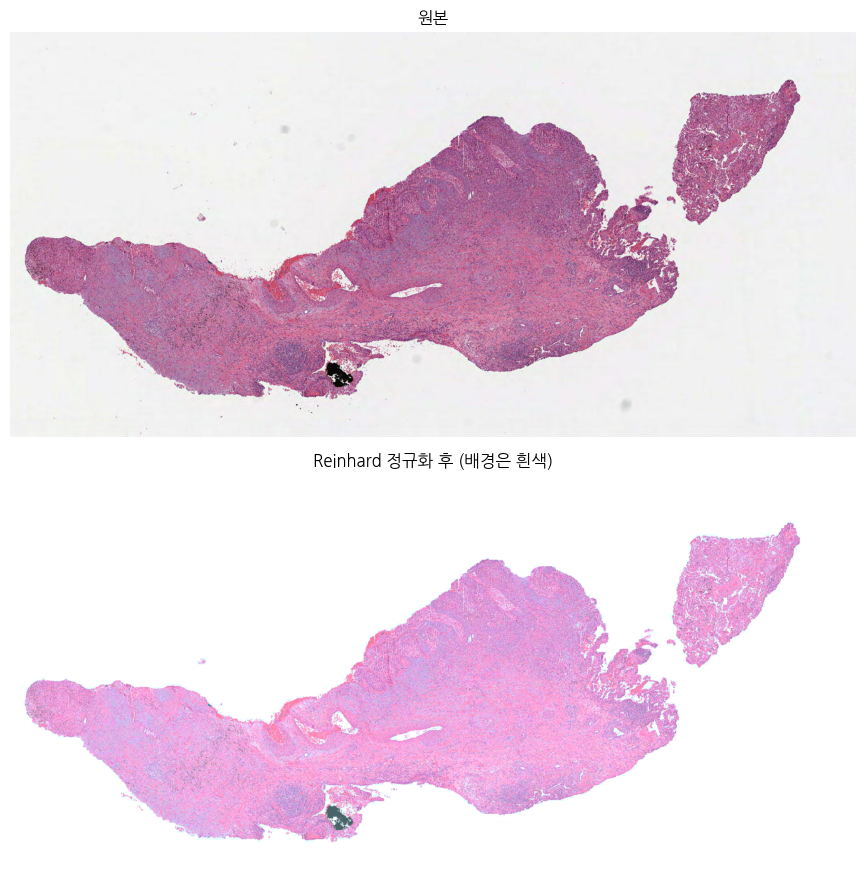

In [7]:
thumb = np.array(slide.get_thumbnail((1600, 1600)).convert("RGB"))
DS = slide.dimensions[0] / thumb.shape[1]  # 썸네일 1px = level-0 DS px

fig, ax = plt.subplots(2, 1, figsize=(16, 9))
ax[0].imshow(thumb); ax[0].set_title("원본")
ax[1].imshow(reinhard(thumb, block=max(1, int(128 / DS)))); ax[1].set_title("Reinhard 정규화 후 (배경은 흰색)")
[a.axis("off") for a in ax]
plt.tight_layout(); plt.show()

## 3. 패치 하나로 보는 HNE2Cell의 출력

40x 슬라이드에서 256×256 패치를 읽고 → 정규화 → 모델 → 공식 후처리 순서로 진행합니다.

In [8]:
def read_rgb(x, y, w, h):
    return np.array(slide.read_region((x, y), 0, (w, h)).convert("RGB"))

def postprocess(out, i=0, magnification=40):
    """모델 출력 → 세포 리스트 (공식 inference.py의 process_batch와 같은 순서)"""
    ct, nb, hv, tt = (out[k][i] for k in ["cell_type_map", "nuclei_binary_map", "hv_map", "tissue_type_map"])
    pred_map = np.concatenate([
        tt.argmax(0)[..., None].numpy(), ct.argmax(0)[..., None].numpy(),
        nb.argmax(0)[..., None].numpy(), hv.permute(1, 2, 0).numpy()], axis=-1)
    pp = DetectionCellPostProcessor(nr_types=ct.shape[0], magnification=magnification, gt=False)
    _, cells = pp.post_process_cell_segmentation(pred_map)
    return [dict(centroid=np.asarray(c["centroid"], float), contour=np.asarray(c["contour"]), type=c["type"],
                 type_prob=c["type_prob"]) for c in cells.values() if c["type"] > 0]

def draw(img, cells, color_fn, thickness=1, offset=(0, 0)):
    canvas = img.copy()
    for c in cells:
        cnt = (c["contour"] + np.asarray(offset)).astype(np.int32).reshape(-1, 1, 2)
        cv2.drawContours(canvas, [cnt], -1, color_fn(c), thickness)
    return canvas

t2_color = lambda c: COLORS[c["type"]]
t1_color = lambda c: TIER1_COLORS[TIER2_TO_TIER1[CELL_TYPES[c["type"]]]]

### 3-1. 원시 출력

종양과 면역세포가 섞인 영역의 256×256 패치 하나를 봅니다. 모델 입력은 224×224이지만 디코더가 **256×256으로 다시 올려서** 출력하므로, 결과 좌표는 원래 패치 좌표와 같습니다.

- `nuclei_binary_map`, `hv_map`: CellViT와 같은 핵 분할 출력 (핵 확률 + 수평/수직 거리)
- `cell_type_map`: 픽셀별 16클래스(배경 + 15종) 확률 → 핵 안에서 다수결로 세포 타입 결정
- `tissue_type_map`(6채널, 픽셀별), `organ_types`(13개, 패치별): 학습 시 보조 출력으로 보이며, **공개된 config에 클래스 이름이 없고 공식 후처리에서도 쓰지 않습니다.** 이 튜토리얼에서도 해석하지 않습니다.

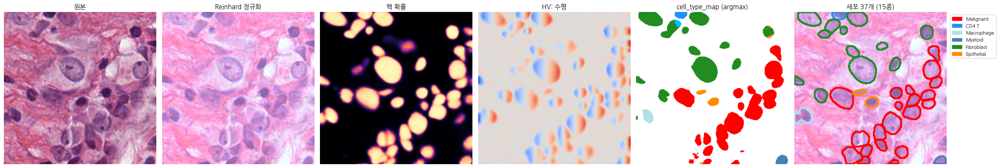

In [9]:
# §4에서 쓸 관심 영역(ROI): 종양과 림프 소포(B/T 세포 집합)가 함께 있는 6,144×6,144 px ≈ 1.5×1.5 mm (level-0 좌표)
ROI_X, ROI_Y, ROI_SIZE = 10240, 6656, 6144
PATCH_XY = (ROI_X + 1600, ROI_Y + 5120)  # 종양-림프구 경계의 한 패치
raw = read_rgb(*PATCH_XY, 256, 256)
img = reinhard(raw)
out = run_model(img[None])
cells = postprocess(out)

nb_prob = F.softmax(out["nuclei_binary_map"][0], 0)[1].numpy()
hv = out["hv_map"][0].numpy()
ct = out["cell_type_map"][0].argmax(0).numpy()
ct_rgb = np.full((*ct.shape, 3), 255, np.uint8)
for k, col in COLORS.items():
    ct_rgb[ct == k] = col

fig, ax = plt.subplots(1, 6, figsize=(26, 4.6))
panels = [(raw, "원본", None), (img, "Reinhard 정규화", None), (nb_prob, "핵 확률", "magma"),
          (hv[0], "HV: 수평", "coolwarm"), (ct_rgb, "cell_type_map (argmax)", None),
          (draw(img, cells, t2_color, 2), f"세포 {len(cells)}개 (15종)", None)]
for a, (im, title, cmap) in zip(ax, panels):
    a.imshow(im, cmap=cmap); a.set_title(title); a.axis("off")
present = sorted({c['type'] for c in cells})
legend(ax[-1], [(CELL_TYPES[k], COLORS[k]) for k in present])
plt.tight_layout(); plt.show()

## 4. 슬라이드 영역(또는 전체) 추론

공식 파이프라인과 같은 방식으로 **256px 패치를 64px씩 겹쳐**(stride 192) 자릅니다. 겹친 영역의 세포가 두 번 세어지지 않도록, 각 패치에서 **가운데 192×192(가장자리 32px 제외)** 에 중심이 있는 세포만 남깁니다. 이웃 패치의 가운데 영역들이 빈틈없이 맞물리므로 중복도 누락도 없습니다.

> 공식 `inference.py`는 중복 제거 없이 패치별 결과를 그대로 CSV에 씁니다. 이 예제 슬라이드 전체에서 공식 CSV는 **128,409행**이지만, 위 규칙으로 중복을 지우면 **68,125개**로 README의 기대값(약 63,000개)에 가까워집니다. 또 공식 CSV에는 `Background`(type 0)로 판정된 객체가 약 17% 섞여 있는데, 이 노트북은 이를 제외합니다.

| 설정 | 영역 | 패치 수 | Colab T4 예상 |
|---|---|---|---|
| `FULL_SLIDE = False` (기본) | 6,144×6,144 px ROI (약 1.5×1.5 mm) | 약 1,000 | 2~4분 |
| `FULL_SLIDE = True` | 조직 전체 | 약 7,000 | 20~30분 |

In [10]:
FULL_SLIDE = False
BATCH = 16  # T4에서 GPU 메모리 약 6GB
P, OV = 256, 64
STRIDE, M = P - OV, OV // 2

x_range = (0, W) if FULL_SLIDE else (ROI_X, ROI_X + ROI_SIZE)
y_range = (0, H) if FULL_SLIDE else (ROI_Y, ROI_Y + ROI_SIZE)
# 패치 시작점을 공식 patchify.py의 전역 격자(0, 192, 384, ...)에 맞춤 → 같은 패치가 잘려 결과가 일치
snap = lambda v: -(-v // STRIDE) * STRIDE
xs = list(range(snap(x_range[0]), x_range[1] - P + 1, STRIDE))
ys = list(range(snap(y_range[0]), y_range[1] - P + 1, STRIDE))

# 조직 패치만 (level-1 썸네일의 채도로 판단)
low_hsv = cv2.cvtColor(low, cv2.COLOR_RGB2HSV)[..., 1] / 255.0
d1 = slide.level_downsamples[lvl]
def is_tissue(x, y, thr=0.1):
    r0, c0 = int(y / d1), int(x / d1)
    return low_hsv[r0:r0 + int(P / d1) + 1, c0:c0 + int(P / d1) + 1].mean() >= thr

jobs = [(x, y) for y in ys for x in xs if is_tissue(x, y)]
print(f"패치 {len(jobs)}개 (전체 격자 {len(xs) * len(ys)}개 중 조직)")

패치 800개 (전체 격자 961개 중 조직)


In [11]:
from tqdm.auto import tqdm

def keep_core(c, x, y):
    """겹침 영역 중복 제거: 패치 가운데 영역(격자 가장자리 패치는 바깥쪽까지)에 중심이 있는 세포만"""
    cx, cy = c["centroid"]
    lo_x = 0 if x == xs[0] else M; hi_x = P if x == xs[-1] else P - M
    lo_y = 0 if y == ys[0] else M; hi_y = P if y == ys[-1] else P - M
    return lo_x <= cx < hi_x and lo_y <= cy < hi_y

records, contours = [], []
t0 = time.time()
for b in tqdm(range(0, len(jobs), BATCH), desc="HNE2Cell"):
    batch = jobs[b:b + BATCH]
    imgs = np.stack([reinhard(read_rgb(x, y, P, P)) for x, y in batch])
    out = run_model(imgs)
    for i, (x, y) in enumerate(batch):
        for c in postprocess(out, i):
            if not keep_core(c, x, y):
                continue
            name = CELL_TYPES[c["type"]]
            gx, gy = c["centroid"] + (x, y)
            records.append(dict(x=gx, y=gy, type=c["type"], cell_type=name, tier1=TIER2_TO_TIER1[name],
                                type_prob=c["type_prob"], area_um2=cv2.contourArea(c["contour"].astype(np.float32)) * MPP ** 2))
            contours.append(c["contour"] + (x, y))

cells_df = pd.DataFrame(records)
dt = time.time() - t0
print(f"{len(cells_df):,}개 세포 | {dt:.0f}s ({len(jobs) / dt:.1f} 패치/s)")
cells_df.head()

HNE2Cell:   0%|          | 0/50 [00:00<?, ?it/s]

8,476개 세포 | 71s (11.3 패치/s)


,x,y,type,cell_type,tier1,type_prob,area_um2
0,13822.715753,6727.770548,15,Dead,Dead,0.982877,16.415784
1,13852.282609,6751.557971,15,Dead,Dead,0.905797,7.271208
2,13752.758242,6767.648352,15,Dead,Dead,1.000000,15.590232
3,13853.840580,6768.594203,15,Dead,Dead,0.150725,19.845000
4,13775.954545,6773.276224,15,Dead,Dead,0.940559,16.415784


## 5. 단일세포 지도와 공간 분석

### 5-1. 세포 지도

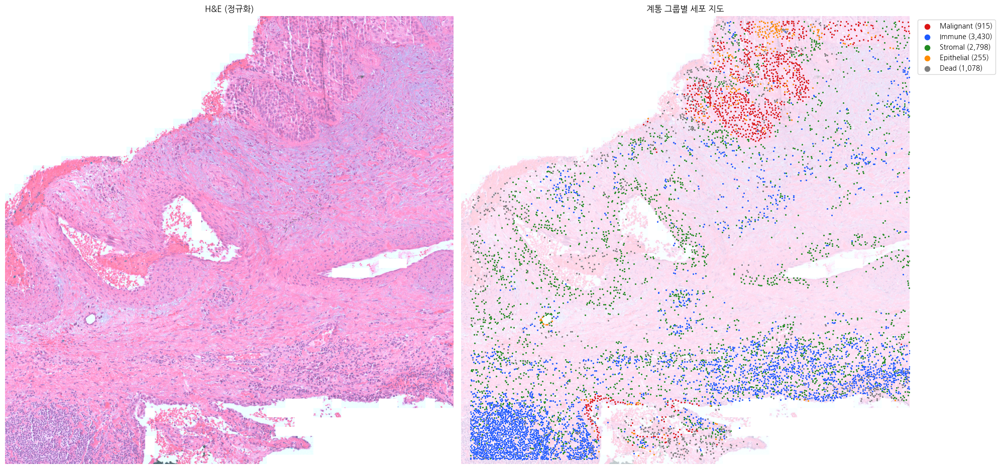

In [12]:
x0, x1 = x_range; y0, y1 = (y_range[0], min(y_range[1], H))
if FULL_SLIDE:
    view, vs, ox, oy = thumb, DS, 0, 0
else:
    view = reinhard(read_rgb(x0, y0, x1 - x0, y1 - y0)[::4, ::4], block=32)
    vs, ox, oy = 4, x0, y0

fig, ax = plt.subplots(1, 2, figsize=(20, 9.5))
ax[0].imshow(view); ax[0].set_title("H&E (정규화)")
ax[1].imshow(view, alpha=0.35)
for t1, col in TIER1_COLORS.items():
    d = cells_df[cells_df.tier1 == t1]
    ax[1].scatter((d.x - ox) / vs, (d.y - oy) / vs, s=1.5, color=np.array(col) / 255, label=f"{t1} ({len(d):,})")
ax[1].legend(markerscale=6, loc="upper left", bbox_to_anchor=(1.01, 1)); ax[1].set_title("계통 그룹별 세포 지도")
[a.axis("off") for a in ax]
plt.tight_layout(); plt.show()

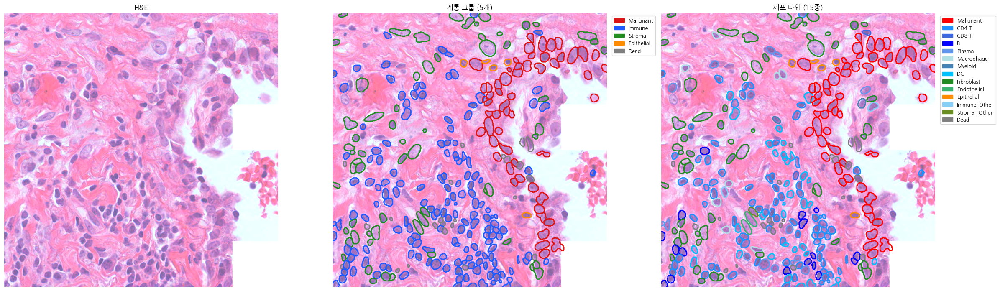

In [13]:
# 확대: 같은 영역을 계통 그룹 / 15종으로
zx, zy, zs = ROI_X + 1280, ROI_Y + 5120, 768  # 종양 · 림프 소포 · 기질이 만나는 곳
zimg = reinhard(read_rgb(zx, zy, zs, zs))
zc = [dict(contour=cnt - (zx, zy), type=t) for cnt, t, (cx, cy) in zip(contours, cells_df.type, cells_df[["x", "y"]].values)
      if zx <= cx < zx + zs and zy <= cy < zy + zs]
fig, ax = plt.subplots(1, 3, figsize=(24, 8))
ax[0].imshow(zimg); ax[0].set_title("H&E")
ax[1].imshow(draw(zimg, zc, t1_color, 2)); ax[1].set_title("계통 그룹 (5개)")
ax[2].imshow(draw(zimg, zc, t2_color, 2)); ax[2].set_title("세포 타입 (15종)")
legend(ax[1], list(TIER1_COLORS.items()))
legend(ax[2], [(CELL_TYPES[k], COLORS[k]) for k in sorted({c['type'] for c in zc})])
[a.axis("off") for a in ax]
plt.tight_layout(); plt.show()

### 5-1b. 조직 사진에서 직접 확인하기

아래 그림들은 **색 정규화 전 원본 H&E**에 결과를 겹쳐 보여 줍니다.

1. **인터랙티브 뷰어** (2,048×2,048 px, 원본 해상도): 휠로 확대, 세포에 마우스를 올리면 타입·확신도·면적, 범례로 타입 켜고 끄기
2. **슬라이드 탐색기**: 슬라이더로 ROI 안 아무 곳이나 원본 해상도로 보기 (Colab/Jupyter에서 동작)
3. **타입별 세포 갤러리**: 15종 각각으로 분류된 실제 세포 사진 — 같은 줄끼리 형태가 비슷한지 확인

In [14]:
CELL_OBJS = [dict(contour=cnt, centroid=(x, y), type=t, name=n, prob=p, area=a)
             for cnt, t, n, p, a, x, y in zip(contours, cells_df.type, cells_df.cell_type, cells_df.type_prob,
                                               cells_df.area_um2, cells_df.x, cells_df.y)]
hne_color = lambda c: COLORS[c["type"]]
hne_label = lambda c: c["name"]
hne_hover = lambda c: f"<b>{c['name']}</b> ({TIER2_TO_TIER1[c['name']]})<br>확신도 {c['prob']:.2f}<br>핵 면적 {c['area']:.0f} µm²"
HNE_ORDER = [CELL_TYPES[k] for k in range(1, 16)]

vx, vy, vs_ = ROI_X + 512, ROI_Y + 4096, 2048  # 종양 · 림프 소포 경계
sub = [c for c in CELL_OBJS if vx <= c["centroid"][0] < vx + vs_ and vy <= c["centroid"][1] < vy + vs_]
viz.interactive(read_rgb(vx, vy, vs_, vs_), sub, hne_color, hne_label, hover_of=hne_hover, order=HNE_ORDER,
                offset=(vx, vy), title=f"HNE2Cell 15종 — 원본 H&E {vs_}×{vs_}px (휠로 확대, 범례 클릭)", height=850)

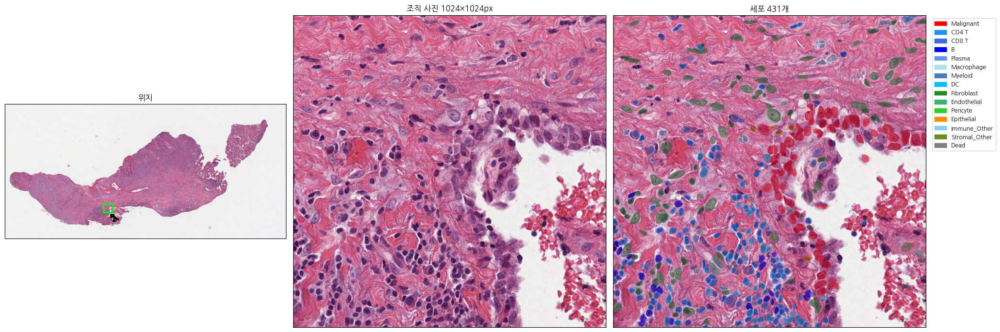

In [15]:
viz.region_explorer(read_rgb, cells_df[["x", "y"]].values, CELL_OBJS, hne_color, hne_label,
                    [(CELL_TYPES[k], COLORS[k]) for k in range(1, 16)], thumb, DS,
                    x_range=x_range, y_range=(y_range[0], min(y_range[1], H)),
                    init=(ROI_X + 1700, ROI_Y + 5400), sizes=(256, 512, 1024, 2048))

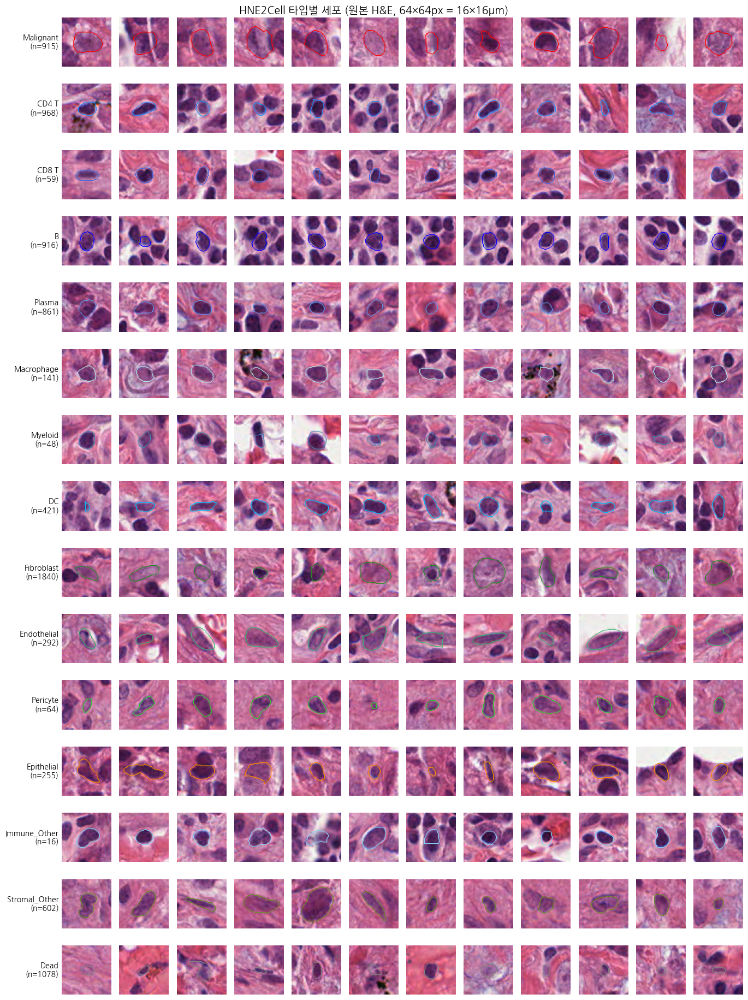

In [16]:
viz.cell_gallery(CELL_OBJS, hne_label, hne_color, order=HNE_ORDER, get_crop=lambda x, y, s: read_rgb(x, y, s, s),
                 n=12, size=64, title="HNE2Cell 타입별 세포 (원본 H&E, 64×64px = 16×16µm)")

### 5-2. 세포 조성

타입별 세포 수·비율, **모델 확신도**(`type_prob`: 핵 안 픽셀 중 다수결 타입 비율), **핵 면적** 분포입니다. 정답 라벨이 없으므로 정확도 대신 확신도를 보여 줍니다 — 확신도가 낮은 타입(예: 드문 면역세포)은 해석에 주의하세요.

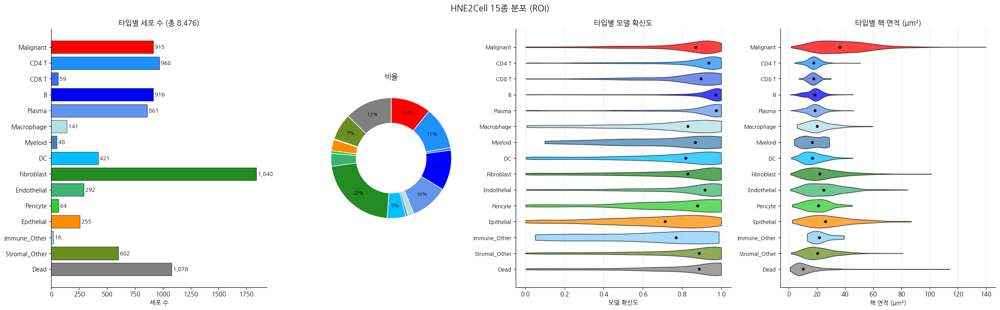

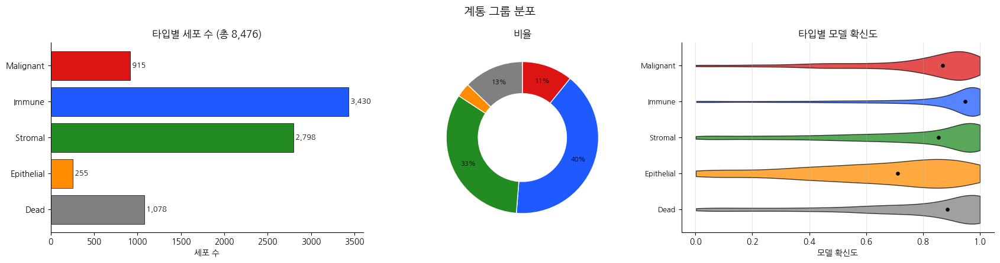

In [17]:
viz.type_summary(cells_df, "cell_type", {CELL_TYPES[k]: COLORS[k] for k in range(1, 16)}, order=HNE_ORDER,
                 value_cols={"type_prob": "모델 확신도", "area_um2": "핵 면적 (µm²)"},
                 title="HNE2Cell 15종 분포 (ROI)")
viz.type_summary(cells_df, "tier1", TIER1_COLORS, order=list(TIER1_COLORS),
                 value_cols={"type_prob": "모델 확신도"}, title="계통 그룹 분포")

### 5-3. 공간 분석 예시

HNE2Cell의 가치는 **세포 타입 + 위치**를 슬라이드 전체에서 얻는 데 있습니다. 두 가지 간단한 지표를 계산해 봅니다.

1. **종양 침윤**: 각 면역세포 타입 중 종양세포 30 µm 이내에 있는 비율 (종양 안/경계 vs 기질)
2. **TLS(3차 림프 구조) 후보**: B세포와 CD4 T세포가 빽빽하게 모인 군집 (DBSCAN)

> TLS를 엄밀하게 정의하려면 형태·구성·위치 기준이 더 필요합니다. 여기서는 개념을 보여주는 단순화된 예시입니다.

In [18]:
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN

um = lambda px: px * MPP
xy = cells_df[["x", "y"]].values
tumor = cells_df.cell_type == "Malignant"
dist_to_tumor, _ = cKDTree(xy[tumor]).query(xy) if tumor.any() else (np.full(len(xy), np.inf), None)
cells_df["dist_to_tumor_um"] = um(dist_to_tumor)

immune = TIER1["Immune"]
infil = (cells_df[cells_df.cell_type.isin(immune)]
         .assign(near=lambda d: d.dist_to_tumor_um <= 30)
         .groupby("cell_type").near.agg(["size", "mean"]).reindex(immune).dropna())
infil.columns = ["세포 수", "종양 30µm 이내 비율"]
print(infil.round(3))

# TLS 후보: B + CD4 T 세포를 25 µm 반경으로 묶고, 50개 이상 & B 비율 ≥ 30%인 군집
lym = cells_df[cells_df.cell_type.isin(["B", "CD4 T"])]
lab = DBSCAN(eps=25 / MPP, min_samples=15).fit_predict(lym[["x", "y"]].values) if len(lym) else []
lym = lym.assign(cluster=lab)
tls = (lym[lym.cluster >= 0].groupby("cluster")
       .agg(n=("x", "size"), b_frac=("cell_type", lambda s: (s == "B").mean()), x=("x", "mean"), y=("y", "mean"))
       .query("n >= 50 and b_frac >= 0.3"))
print(f"\nTLS 후보 {len(tls)}개")
print(tls.round(2))

              세포 수  종양 30µm 이내 비율
cell_type                        
CD4 T          968          0.037
CD8 T           59          0.169
B              916          0.007
Plasma         861          0.013
Macrophage     141          0.085
Myeloid         48          0.083
DC             421          0.076
Immune_Other    16          0.125

TLS 후보 1개
            n  b_frac         x         y
cluster                                  
4        1282    0.69  11013.29  12410.16


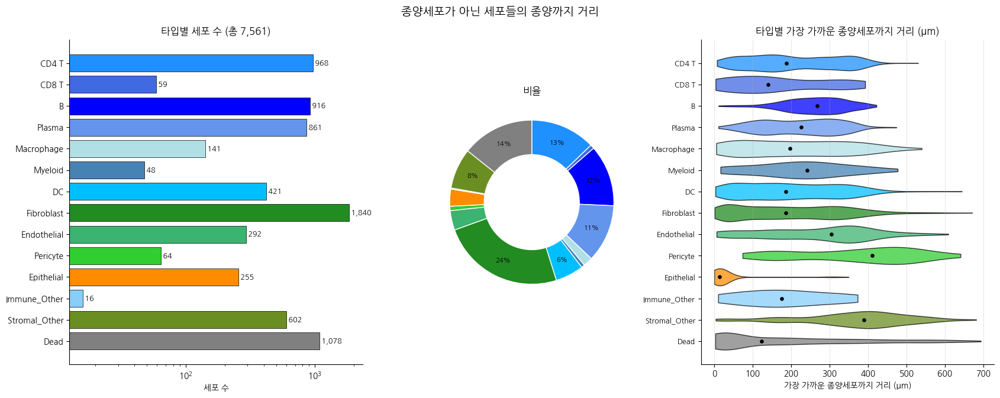

In [19]:
# 타입별 '가장 가까운 종양세포까지 거리' 분포 — 어떤 세포가 종양 가까이(안쪽) 있고 어떤 세포가 멀리(기질·림프 소포) 있는지
non_tumor = cells_df[cells_df.cell_type != "Malignant"]
viz.type_summary(non_tumor, "cell_type", {CELL_TYPES[k]: COLORS[k] for k in range(1, 16)}, order=HNE_ORDER[1:],
                 value_cols={"dist_to_tumor_um": "가장 가까운 종양세포까지 거리 (µm)"}, log_count=True,
                 title="종양세포가 아닌 세포들의 종양까지 거리")

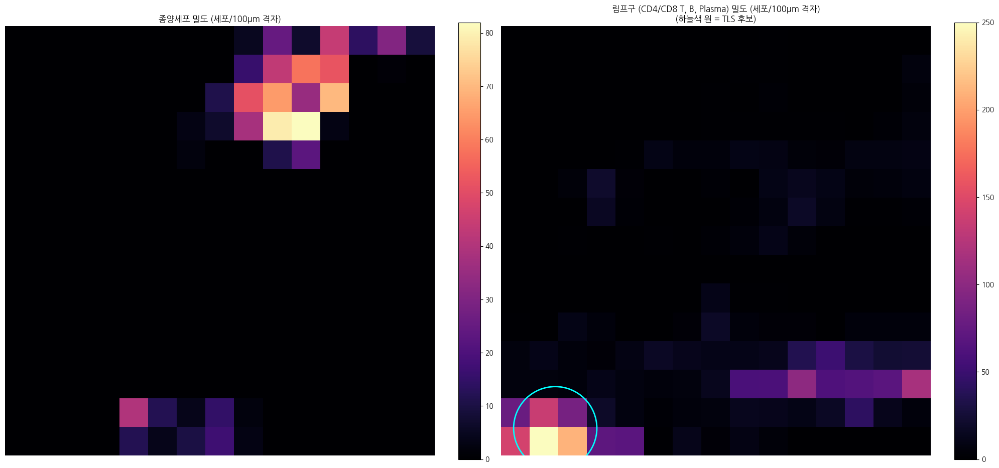

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(20, 9.5))
# 면역세포 밀도 (100 µm 격자)
bins = [np.arange(x0, x1 + 1, 100 / MPP), np.arange(y0, y1 + 1, 100 / MPP)]
for a, (name, types) in zip(ax, [("종양세포", ["Malignant"]), ("림프구 (CD4/CD8 T, B, Plasma)", ["CD4 T", "CD8 T", "B", "Plasma"])]):
    d = cells_df[cells_df.cell_type.isin(types)]
    h, _, _ = np.histogram2d(d.x, d.y, bins=bins)
    im = a.imshow(h.T, cmap="magma", extent=[0, (x1 - x0) / vs, (y1 - y0) / vs, 0])
    a.set_title(f"{name} 밀도 (세포/100µm 격자)"); a.axis("off"); plt.colorbar(im, ax=a, fraction=0.046)
for _, r in tls.iterrows():
    ax[1].add_patch(plt.Circle(((r.x - ox) / vs, (r.y - oy) / vs), 150 / MPP / vs, fill=False, ec="cyan", lw=2))
ax[1].set_title(ax[1].get_title() + "\n(하늘색 원 = TLS 후보)")
plt.tight_layout(); plt.show()

## 6. 결과 내보내기

- `cells.csv`: 세포별 좌표(level-0 px), 타입, 계통 그룹, 확률, 면적, 종양까지 거리 → pandas / Seurat / squidpy로 후속 분석
- `cells.geojson`: QuPath에서 `File → Import objects`로 원본 슬라이드 위에 겹쳐 보기

In [21]:
OUT = WORKDIR / "outputs"; OUT.mkdir(exist_ok=True)
cells_df.to_csv(OUT / "cells.csv", index=False)

features = [{
    "type": "Feature",
    "geometry": {"type": "Polygon", "coordinates": [cnt.tolist() + [cnt[0].tolist()]]},
    "properties": {"objectType": "detection", "classification": {"name": n, "color": list(COLORS[t])}},
} for cnt, n, t in zip(contours, cells_df.cell_type, cells_df.type)]
(OUT / "cells.geojson").write_text(json.dumps({"type": "FeatureCollection", "features": features}))
!ls -lh {OUT}

합계 6.6M
-rw-rw-r-- 1 hjpark hjpark 865K 10월  6 10:55 cells.csv
-rw-rw-r-- 1 hjpark hjpark 5.8M 10월  6 10:55 cells.geojson


## 정리

| 단계 | 핵심 |
|---|---|
| 입력 | 40x H&E, **Reinhard 정규화 필수**, 256px 패치(64px 겹침) → 224로 축소 |
| 모델 | 대형 ViT encoder + CellViT식 디코더 (약 1.3B 파라미터), TorchScript |
| 출력 | 핵 분할 + 15종 세포 타입 (5개 계통 그룹으로 묶을 수 있음) |
| 후처리 | 공식 `post_processing.py` (watershed), 겹침 영역은 패치 가운데만 남겨 중복 제거 |

**주의할 점**
- CD4⁺/CD8⁺ T 세포는 H&E에서 형태가 거의 같아 구분이 본질적으로 어렵습니다. 정량 분석에서는 합쳐서 'T 세포'로 보는 것이 안전합니다.
- 20x 슬라이드도 동작하지만(`DetectionCellPostProcessor(magnification=20)`) 작은 면역세포 정확도가 떨어집니다.
- 모델 가중치는 **CC BY-NC 4.0** (비상업적 연구용). 상업적 이용은 이화여대 산학협력단 문의.

**CellViT/CellViT++와의 관계**: HNE2Cell은 CellViT의 디코더 구조와 후처리를 그대로 이어받고, encoder를 대형 병리 ViT로 바꾼 뒤 **공간전사체 라벨로 학습**해 세포 타입을 15종까지 늘린 모델입니다.